In [1]:
# === System & OS Utilities ===
import os
import math
import pickle
import sys
import warnings
import random
import logging
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adamax, AdamW
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.layers import Layer
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Conv2D, 
                                     Dense,
                                     Dropout,
                                     Flatten,
                                     GlobalAveragePooling2D,
                                     GlobalMaxPooling2D,
                                     MaxPooling2D,
                                     BatchNormalization,
                                     ReLU,
                                     Add)
from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Multiply, Add, Activation, Concatenate
)
import os, numpy as np, cv2
from skimage.feature import local_binary_pattern
from tensorflow.keras import layers, Model, initializers
from tensorflow.keras.layers import Layer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# === Scikit-learn ===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

In [2]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
TensorFlow version: 2.16.2
Keras version: 3.5.0
NumPy version: 1.26.4
Pandas version: 2.2.3
OpenCV version: 4.6.0
Matplotlib version: 3.7.5
Seaborn version: 0.12.2
Scikit-learn version: 1.2.2


In [3]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 100
img_shape=(*IMG_SIZE,3)
dataset_path = r"/kaggle/input/preprocessed-augmented-breakhis-dataset/preprocessed_breakhis_dataset/vahadane_normalized"
labels = ['Benign', 'Malignant']
print("Class Names:", labels)

Class Names: ['Benign', 'Malignant']


In [6]:
def data_frame(root_path, target_folder):

    class_paths = []
    classes = []
    patient_ids = []

    for label in os.listdir(root_path):

        class_dir = os.path.join(root_path, label)
        if not os.path.isdir(class_dir):
            continue

        target_dir = os.path.join(class_dir, target_folder)

        if not os.path.isdir(target_dir):
            print(f"[WARNING] '{target_folder}' not found in class '{label}'. Skipping.")
            continue

        for image in os.listdir(target_dir):

            if not image.lower().endswith(('.png','.jpg','.jpeg')):
                continue

            path = os.path.join(target_dir,image)

            parts = image.split('-')

            # Skip malformed filenames
            if len(parts) < 3:
                print(f"Skipping malformed filename: {image}")
                continue

            patient_id = parts[1] + "-" + parts[2]

            class_paths.append(path)
            classes.append(label)
            patient_ids.append(patient_id)

    df = pd.DataFrame({
        'Class Path': class_paths,
        'Class': classes,
        'PatientID': patient_ids
    })

    return df

In [ ]:
main_frame = data_frame(
    root_path=dataset_path,
    target_folder="100X"   # "40X", "100X", "200X", "400X"
)

patients = main_frame['PatientID'].unique()

train_pat, temp_pat = train_test_split(
    patients,
    test_size=0.20,
    random_state=42
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.5,
    random_state=42
)

train_dataframe = main_frame[main_frame['PatientID'].isin(train_pat)]
validation_dataframe = main_frame[main_frame['PatientID'].isin(val_pat)]
test_dataframe = main_frame[main_frame['PatientID'].isin(test_pat)]


print("Train patients:",len(set(train_dataframe.PatientID)))
print("Val patients:",len(set(validation_dataframe.PatientID)))
print("Test patients:",len(set(test_dataframe.PatientID)))

print("Overlap train-val:",set(train_dataframe.PatientID) & set(validation_dataframe.PatientID))
print("Overlap train-test:",set(train_dataframe.PatientID) & set(test_dataframe.PatientID))
print("Overlap val-test:",set(validation_dataframe.PatientID) & set(test_dataframe.PatientID))
print()
train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

count_table = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).fillna(0).astype(int)

count_table["Total"] = count_table.sum(axis=1)
grand_total = pd.DataFrame({
    "Train": [count_table["Train"].sum()],
    "Validation": [count_table["Validation"].sum()],
    "Test": [count_table["Test"].sum()],
    "Total": [count_table["Total"].sum()]
}, index=["Total"])
count_table = pd.concat([count_table, grand_total])

print(count_table)

BATCH_SIZE = min(BATCH_SIZE, len(validation_dataframe))
print(f"Batch Size = {BATCH_SIZE}")

Train patients: 64
Val patients: 8
Test patients: 9
Overlap train-val: set()
Overlap train-test: set()
Overlap val-test: set()

           Train  Validation  Test  Total
Benign      1353         112    35   1500
Malignant   1155         144   201   1500
Total       2508         256   236   3000
Batch Size = 32


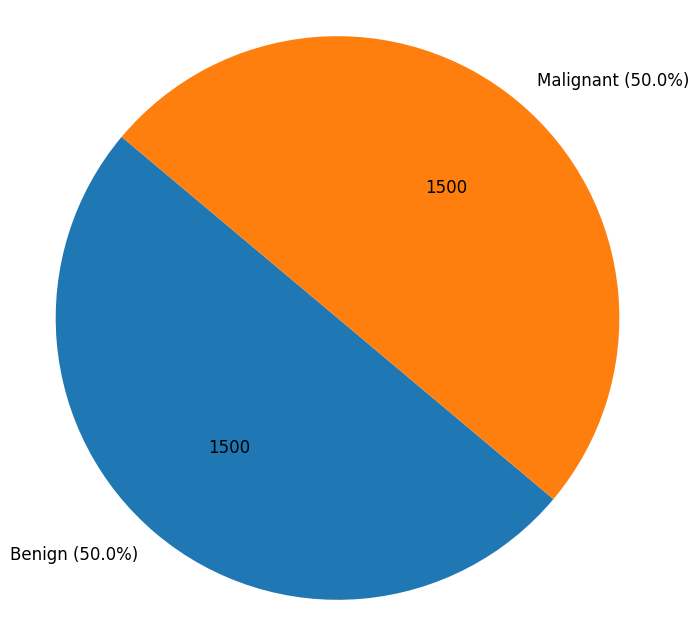

In [8]:
# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

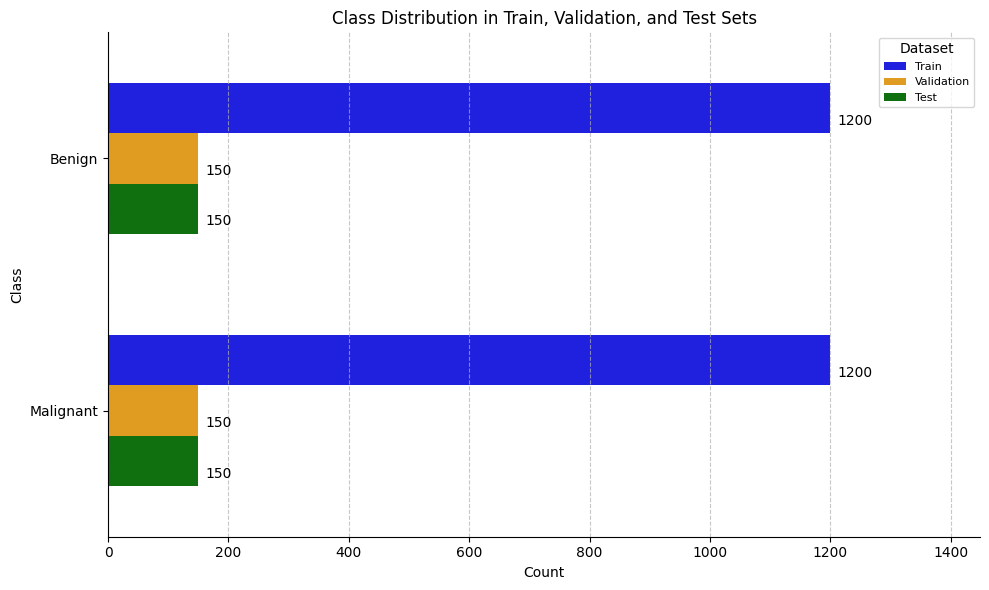

In [9]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [10]:
def preprocess_image(image):

    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    # avoid division by zero
    if max_val - min_val < 1e-6:
        return np.zeros_like(image, dtype=np.float32)

    # min-max scale to [0, 1]
    image = (image - min_val) / (max_val - min_val)
    
    return image

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,

    # ---- Geometric ----
    rotation_range=30,         
    zoom_range=0.1,           
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,

    horizontal_flip=True,
    vertical_flip=True,

    fill_mode="reflect"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, class_mode='binary', seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, class_mode='binary', seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, class_mode='binary', shuffle=False, seed=42)

Found 2400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


In [12]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"\nModel weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"Restoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [13]:
######## Main Model which is used in this study of breast cancer###########
# ---------------------------
# Squeeze-and-Excitation
# ---------------------------
@tf.keras.utils.register_keras_serializable()
class SEBlock(layers.Layer):
    def __init__(self, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(C // self.reduction, activation="relu")
        self.fc2 = layers.Dense(C, activation="sigmoid")

    def call(self, x):
        s = self.gap(x)
        s = self.fc1(s)
        s = self.fc2(s)
        s = tf.reshape(s, (-1, 1, 1, x.shape[-1]))
        return x * s


# ---------------------------
# CoordAttention
# ---------------------------
@tf.keras.utils.register_keras_serializable()
class CoordAttention(layers.Layer):
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]
        mip = max(8, C // self.reduction)
        self.conv1 = layers.Conv2D(mip, 1, activation="relu")
        self.conv_h = layers.Conv2D(C, 1)
        self.conv_w = layers.Conv2D(C, 1)

    def call(self, x):
        h = tf.reduce_mean(x, axis=2, keepdims=True)
        w = tf.reduce_mean(x, axis=1, keepdims=True)
        w = tf.transpose(w, [0, 2, 1, 3])

        y = tf.concat([h, w], axis=1)
        y = self.conv1(y)

        h, w = tf.split(y, [tf.shape(h)[1], tf.shape(w)[1]], axis=1)
        w = tf.transpose(w, [0, 2, 1, 3])

        ah = tf.sigmoid(self.conv_h(h))
        aw = tf.sigmoid(self.conv_w(w))
        return x * ah * aw


# ---------------------------
# Ghost Module
# ---------------------------
def GhostModule(x, out_ch, ratio=2):
    init_ch = math.ceil(out_ch / ratio)

    y = layers.Conv2D(init_ch, 1, use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)

    # kernel 3 → 5 (capacity ↑)
    ghost = layers.DepthwiseConv2D(5, padding="same", use_bias=False)(y)
    ghost = layers.BatchNormalization()(ghost)
    ghost = layers.Activation("relu")(ghost)

    y = layers.Concatenate()([y, ghost])
    y = layers.Conv2D(out_ch, 1, use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    return y


# ---------------------------
# Residual Block 
# ---------------------------
def ResidualBlock(x, out_ch, attention=None, drop_rate=0.1):
    shortcut = x

    y = GhostModule(x, out_ch)
    y = layers.Activation("relu")(y)

    if attention == "se":
        y = SEBlock()(y)
    elif attention == "coord":
        y = CoordAttention()(y)

    # spatial dropout stabilizes feature maps
    y = layers.SpatialDropout2D(drop_rate)(y)

    if x.shape[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    return layers.Activation("relu")(layers.Add()([shortcut, y]))


# ---------------------------
# Build FINAL Model 
# ---------------------------
def build_skin_model(input_shape=(224,224,3)):
    inp = Input(shape=input_shape)

    # Stem: kernel 3 → 5
    x = layers.Conv2D(32, 5, strides=2, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Stage 1
    x = ResidualBlock(x, 48, drop_rate=0.05)
    x = ResidualBlock(x, 48, drop_rate=0.05)

    # Stage 2
    x = layers.Conv2D(96, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = ResidualBlock(x, 96, attention="se", drop_rate=0.1)
    x = ResidualBlock(x, 96, attention="se", drop_rate=0.1)

    # Stage 3
    x = layers.Conv2D(160, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = ResidualBlock(x, 160, attention="coord", drop_rate=0.15)
    x = ResidualBlock(x, 160, attention="coord", drop_rate=0.15)
    x = ResidualBlock(x, 160, attention="coord", drop_rate=0.15)

    # Stage 4
    x = layers.Conv2D(224, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = ResidualBlock(x, 224, attention="coord", drop_rate=0.2)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l1_l2(l1=1e-5, l2=1e-4)
    )(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(1, activation="sigmoid", bias_initializer="zeros")(x)

    return Model(inp, x, name="LightWeightBreastCancerDetector")


# ---------------------------
# Build & Summary
# ---------------------------
model = build_skin_model()
model.summary()

I0000 00:00:1765831259.440866      18 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "LightWeightBreastCancerDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      2,400 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │        768 │ activation[0][0]  │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 112, 112,  │        600 │ activation_1[0][… │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (Concatenate)       │ 48)               │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │      2,304 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      1,536 │ activation[0][0]  │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        192 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 112, 112,  │          0 │ activation_3[0][

 Total params: 1,727,369 (6.59 MB)

 Trainable params: 1,722,281 (6.57 MB)

 Non-trainable params: 5,088 (19.88 KB)

In [14]:
"""
# =====================================================
# Token Mixer (Mamba-inspired, lightweight)
# =====================================================
@tf.keras.utils.register_keras_serializable(package="Custom")
class MambaVisionBlock(layers.Layer):
    def __init__(self, embed_dim, expansion=2, kernel_size=5, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        hidden_dim = embed_dim * expansion

        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.expand = layers.Dense(hidden_dim, use_bias=False)
        self.act = layers.Activation("gelu")
        self.token_conv = layers.Conv1D(
            hidden_dim, kernel_size=kernel_size, padding="same", use_bias=False
        )
        self.project = layers.Dense(embed_dim, use_bias=False)
        self.dropout = layers.Dropout(dropout)

    def call(self, x):
        y = self.norm(x)
        y = self.expand(y)
        y = self.act(y)
        y = self.token_conv(y)
        y = self.project(y)
        y = self.dropout(y)
        return x + y


# =====================================================
# Transformer Block (Attention + Mamba)
# =====================================================
def ViT_Mamba_Block(x, embed_dim, num_heads, mlp_dim, dropout=0.1):
    # --- Self-attention ---
    skip = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout
    )(x, x)

    x = layers.Add()([skip, attn])

    # --- Mamba token mixer ---
    x = MambaVisionBlock(
        embed_dim=embed_dim,
        expansion=2,
        kernel_size=5,
        dropout=dropout
    )(x)

    # --- MLP ---
    skip2 = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(mlp_dim, activation="gelu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(embed_dim)(x)

    return layers.Add()([skip2, x])


# =====================================================
# Build 5M-parameter Model
# =====================================================
def build_vit_mamba_5m(
    input_shape=(224, 224, 3),
    patch_size=16,
    embed_dim=128,       
    depth=5,             
    num_heads=5,
    mlp_dim=256,
    stem_stride=2,
    dropout=0.1
):

    H, W = input_shape[:2]

    if patch_size % stem_stride != 0:
        raise ValueError("patch_size must be divisible by stem_stride")

    patch_on_stem = patch_size // stem_stride

    inputs = Input(shape=input_shape)

    # ------------------
    # Conv Stem
    # ------------------
    x = layers.Conv2D(
        embed_dim // 2,
        kernel_size=7,
        strides=stem_stride,
        padding="same",
        use_bias=False
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("gelu")(x)

    x = layers.Conv2D(
        embed_dim // 2,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("gelu")(x)

    # ------------------
    # Patch Embedding
    # ------------------
    x = layers.Conv2D(
        embed_dim,
        kernel_size=patch_on_stem,
        strides=patch_on_stem,
        padding="valid"
    )(x)

    num_patches = (H // patch_size) * (W // patch_size)
    x = layers.Reshape((num_patches, embed_dim))(x)

    # ------------------
    # Transformer + Mamba Blocks
    # ------------------
    for _ in range(depth):
        x = ViT_Mamba_Block(
            x,
            embed_dim=embed_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    # ------------------
    # Token Pooling (NO CLS TOKEN)
    # ------------------
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # ------------------
    # Classification Head
    # ------------------
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="ViT_Mamba_5M")

    return model


# =====================================================
# Instantiate & Summary
# =====================================================
if __name__ == "__main__":
    model = build_vit_mamba_5m(
        input_shape=(224, 224, 3),
        patch_size=16,
        embed_dim=128,
        depth=5,
        num_heads=5,
        mlp_dim=256,
        dropout=0.1
    )

    model.summary()
"""
print("Will use this model for next paper")

Will use this model for next paper


In [15]:
# ===============================
# Dynamic Cosine Decay
# ===============================
num_train_samples = sum(list(train_counts))

steps_per_epoch = math.ceil(num_train_samples / BATCH_SIZE)
decay_steps = steps_per_epoch * EPOCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=decay_steps,
    alpha=1e-3   
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=5e-5,   
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled with optimized AdamW + CosineDecay")
print(f"Train samples: {num_train_samples}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total decay steps: {decay_steps}")


Model compiled with optimized AdamW + CosineDecay
Train samples: 2400
Steps per epoch: 75
Total decay steps: 7500


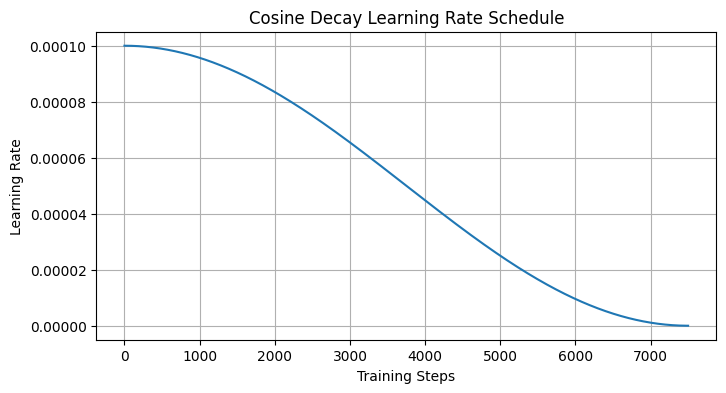

In [16]:
all_steps = np.arange(decay_steps)
lrs = [lr_schedule(step).numpy() for step in all_steps]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,4))
plt.plot(all_steps, lrs)
plt.title("Cosine Decay Learning Rate Schedule")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [17]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCH,
    callbacks=[restore_best],
    verbose=1
)

Epoch 1/100


I0000 00:00:1765831301.582190      57 service.cc:148] XLA service 0x7c4cb0178070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765831301.582883      57 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765831305.564744      57 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/75 ━━━━━━━━━━━━━━━━━━━━ 1:02:08 50s/step - accuracy: 0.5938 - auc: 0.3300 - loss: 0.7979 - precision: 0.6154 - recall: 0.8421

I0000 00:00:1765831327.990598      57 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.5743 - auc: 0.6075 - loss: 0.7423 - precision: 0.5740 - recall: 0.5734
Model weights updated at epoch 1 with val_accuracy: 0.5000
75/75 ━━━━━━━━━━━━━━━━━━━━ 102s 698ms/step - accuracy: 0.5746 - auc: 0.6082 - loss: 0.7418 - precision: 0.5745 - recall: 0.5732 - val_accuracy: 0.5000 - val_auc: 0.6798 - val_loss: 0.7473 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6591 - auc: 0.7326 - loss: 0.6515 - precision: 0.6583 - recall: 0.6478
Model weights updated at epoch 2 with val_accuracy: 0.5000
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 441ms/step - accuracy: 0.6594 - auc: 0.7330 - loss: 0.6512 - precision: 0.6588 - recall: 0.6479 - val_accuracy: 0.5000 - val_auc: 0.6578 - val_loss: 1.5690 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6940 - auc: 0.7743 - loss: 0.6164 - precision: 0.6866 - recall: 0.7201

In [18]:
model.save("Proposed_Model.keras") 

In [19]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [20]:
model = load_model('Proposed_Model.keras')  

In [21]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [22]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']

In [23]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 82:
   - Train Accuracy: 0.9004
   - Val Accuracy:   0.9200

📌 Best Precision at epoch 44:
   - Train Precision: 0.8567
   - Val Precision:   0.9467

📌 Best AUC at epoch 84:
   - Train AUC: 0.9606
   - Val AUC:   0.9714

📌 Best Loss at epoch 82:
   - Train Loss: 0.2781
   - Val Loss:   0.2678



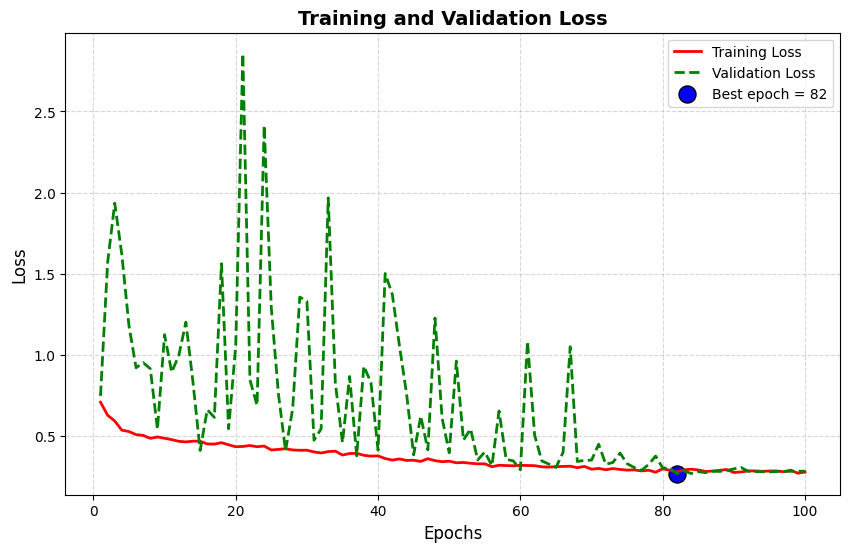

In [24]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

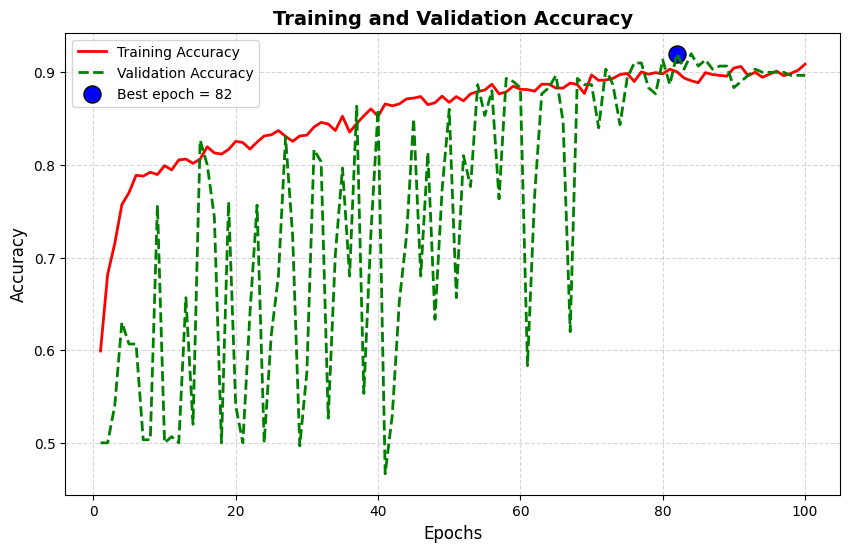

In [25]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


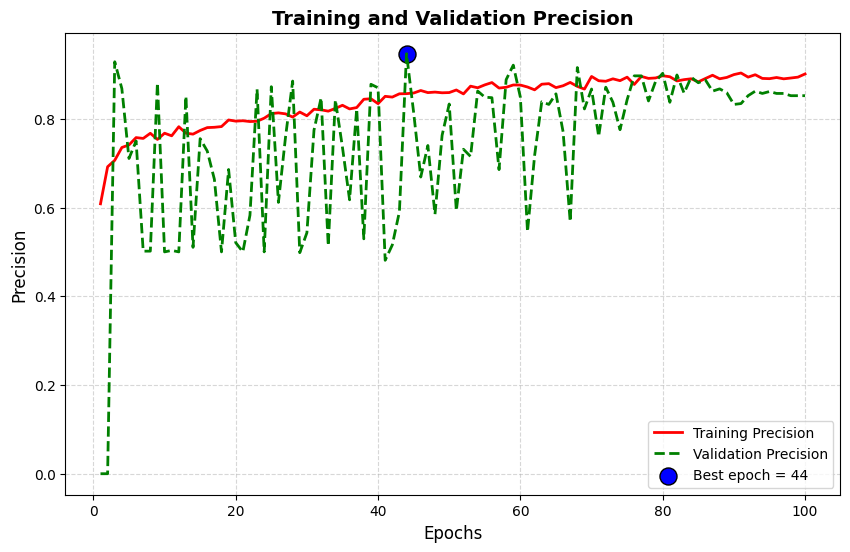

In [26]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


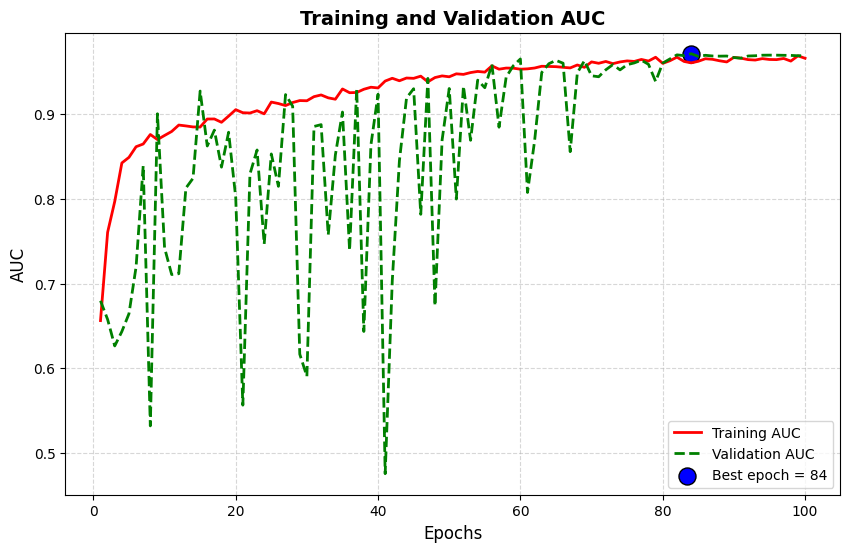

In [27]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


Evaluating: SkinCancerModel
Total steps: 10


Evaluating SkinCancerModel: 100%|██████████| 10/10 [00:10<00:00,  1.05s/it]



Total samples evaluated: 300
Class distribution: [150 150]

PERFORMANCE METRICS
Accuracy  : 0.8767
Precision : 0.8466
Recall    : 0.9200
F1 Score  : 0.8818
AUC       : 0.9595

Classification Report:

              precision    recall  f1-score   support

      Benign       0.91      0.83      0.87       150
    Melanoma       0.85      0.92      0.88       150

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



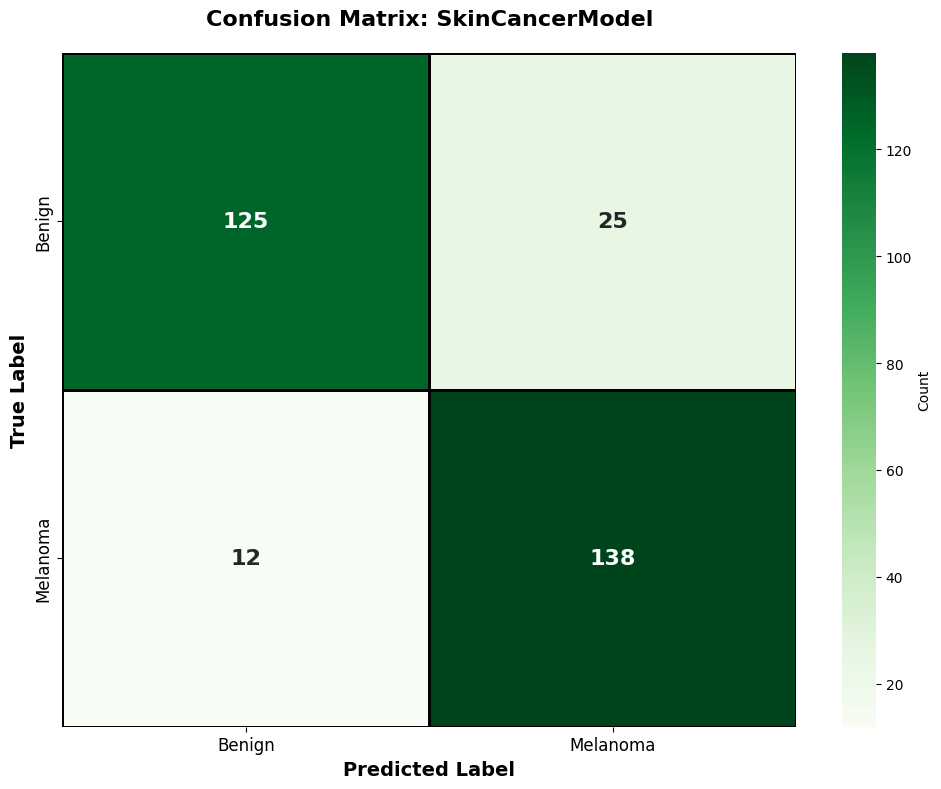

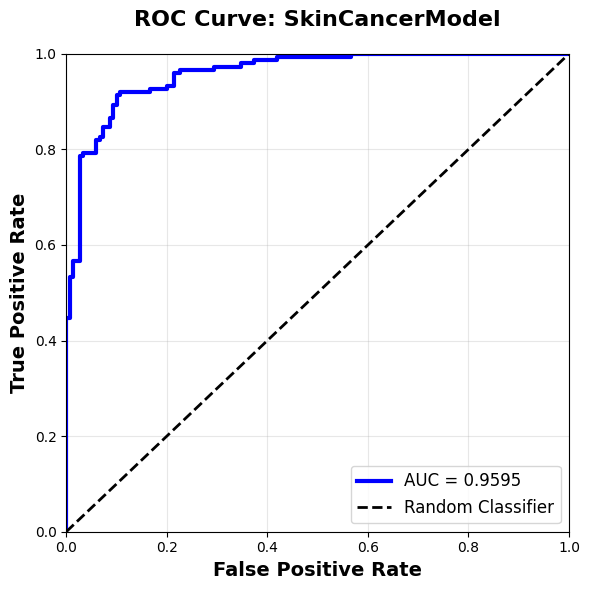


Test Accuracy: 0.8767
Test AUC: 0.9595


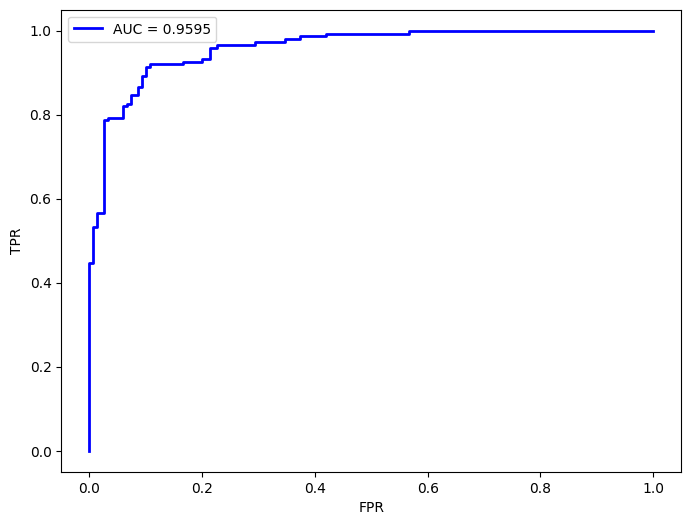

In [28]:

# ==========================================
# Model Evaluation Function
# ==========================================
def evaluate_model(model, test_generator, labels, model_name, batch_size=32):
    """
    Evaluate a trained binary-classification model with dual inputs (image + handcrafted features).

    Args:
        model: Trained Keras model expecting ((img, hf), labels)
        test_generator: HandcraftedGeneratorWrapper instance
        labels: List of class names (e.g., ['Benign', 'Melanoma'])
        model_name: Name for display
        batch_size: Batch size (used for step calculation)

    Returns:
        metrics_dict: Dictionary with all metrics
        auc_curve_data: FPR, TPR for ROC curve plotting
    """

    steps = len(test_generator)

    y_true = []
    y_pred = []
    y_probs = []

    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*80}")
    print(f"Total steps: {steps}")

    # Loop through test generator
    for step_idx in tqdm(range(steps), desc=f"Evaluating {model_name}", total=steps):
        # Get batch from generator
        images, labels_batch = test_generator[step_idx]

        # Predict using both inputs
        preds = model.predict(
            images,
            verbose=0
        )  # sigmoid outputs (probability of class 1)

        preds = preds.reshape(-1)

        y_probs.extend(preds)                      # probability for class 1
        y_pred.extend((preds >= 0.5).astype(int))  # binary classification using threshold 0.5

        # Labels from generator (binary)
        labels_batch = labels_batch.reshape(-1)
        y_true.extend(labels_batch.astype(int))

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    print(f"\nTotal samples evaluated: {len(y_true)}")
    print(f"Class distribution: {np.bincount(y_true)}")

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = float("nan")

    # Classification report
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)

    # Print metrics
    print(f"\n{'='*80}")
    print(f"PERFORMANCE METRICS")
    print(f"{'='*80}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC       : {auc:.4f}")
    print(f"{'='*80}\n")

    print("Classification Report:\n")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        linewidths=2,
        linecolor='black',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"label": "Count"}
    )

    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(f'ROC Curve: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

    auc_curve_data = {"fpr": fpr, "tpr": tpr, "auc": auc}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs,
        "confusion_matrix": cm
    }, auc_curve_data


# Evaluate
metrics, roc_data = evaluate_model(
    model=model,
    test_generator=test_data,
    labels=['Benign', 'Melanoma'],
    model_name='SkinCancerModel',
    batch_size=32
)

# Access results
print(f"\nTest Accuracy: {metrics['accuracy']:.4f}")
print(f"Test AUC: {metrics['auc']:.4f}")

# Plot ROC curve
fpr, tpr, auc = roc_data['fpr'], roc_data['tpr'], roc_data['auc']
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()


----------------
Bootstrap 95% Confidence interval


In [29]:
# -----------------------------
# Parameters
# -----------------------------
B = 1000                # number of bootstrap samples
RNG_SEED = 42

# 1) Get predictions and true labels
probs = model.predict(test_data, verbose=1).ravel()   # shape (N,) after ravel for binary
y_true = np.asarray(test_data.classes)                # shape (N,)
y_pred = (probs >= 0.5).astype(int)                   # thresholding for binary

# Point estimates
point_accuracy = accuracy_score(y_true, y_pred)
point_precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
point_recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
point_f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

# AUC for binary
try:
    point_auc = roc_auc_score(y_true, probs)
except Exception:
    point_auc = np.nan

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 398ms/step


In [30]:
# 2) Bootstrap
rng = np.random.RandomState(RNG_SEED)
metrics_boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
N = len(y_true)

for i in tqdm(range(B), desc="Bootstrap samples"):
    idx = rng.randint(0, N, size=N)   # sample with replacement
    y_true_b, y_pred_b, probs_b = y_true[idx], y_pred[idx], probs[idx]

    metrics_boot["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    metrics_boot["precision"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["recall"].append(recall_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["f1"].append(f1_score(y_true_b, y_pred_b, average='macro', zero_division=0))

    #probs_b = probs_b.ravel()   # ensure shape (N,)
    
    try:
        auc_b = roc_auc_score(y_true_b, probs_b)
    except Exception:
        auc_b = np.nan
    
    metrics_boot["auc"].append(auc_b)


# Convert lists to arrays
for k in metrics_boot:
    metrics_boot[k] = np.array(metrics_boot[k], dtype=np.float32)

Bootstrap samples: 100%|██████████| 1000/1000 [00:04<00:00, 217.06it/s]


In [31]:
# 3) Compute 95% CI
def ci95(arr):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    return np.percentile(arr, [2.5, 97.5])

results = []
for name, point in [
    ("accuracy", point_accuracy),
    ("precision", point_precision),
    ("recall", point_recall),
    ("f1", point_f1),
    ("auc", point_auc)
]:
    lo, hi = ci95(metrics_boot[name])
    results.append({
        "metric": name,
        "point_estimate": point,
        "ci_lower": lo,
        "ci_upper": hi,
        "n_boot_valid": int(np.sum(~np.isnan(metrics_boot[name])))
    })

df_results = pd.DataFrame(results).set_index("metric")
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results)

           point_estimate  ci_lower  ci_upper  n_boot_valid
metric                                                     
accuracy           0.8767    0.8399    0.9133          1000
precision          0.8466    0.8413    0.9159          1000
recall             0.9200    0.8368    0.9132          1000
f1                 0.8818    0.8371    0.9132          1000
auc                0.9595    0.9367    0.9766          1000


In [32]:
def plot_bootstrap_metrics(metrics_boot, df_results, n_cols=3, figsize_per_plot=(5, 4),
                           w_pad=0.6, h_pad=1.5, shift_factor=0.5):
    """
    Plot bootstrap metric distributions.

    Args:
        metrics_boot: dict of metric -> bootstrap array
        df_results: DataFrame with point estimates and CIs
        n_cols: 
            >0 -> number of columns for grid layout
             0 -> plot each metric separately (one figure per metric)
        figsize_per_plot: (width, height) per subplot
        w_pad: horizontal gap between subplots (grid mode only)
        h_pad: vertical gap between subplots (grid mode only)
        shift_factor: how much to center last row if not full (grid mode only)
    """

    metrics = list(metrics_boot.keys())
    n_metrics = len(metrics)

    # --------------------
    # Single-plot mode
    # --------------------
    if n_cols == 0:
        for metric in metrics:
            vals = metrics_boot[metric]
            vals_nonan = vals[~np.isnan(vals)]

            fig, ax = plt.subplots(figsize=figsize_per_plot)
            ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
            ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
            ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
            ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

            ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
        return  # done

    # --------------------
    # Grid mode
    # --------------------
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_plot[0]*n_cols,
                                      figsize_per_plot[1]*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten

    for i, metric in enumerate(metrics):
        ax = axes[i]
        vals = metrics_boot[metric]
        vals_nonan = vals[~np.isnan(vals)]

        ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
        ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
        ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
        ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

        ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
        ax.legend()

        # 🔹 Format x-axis ticks to 2 decimal places
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))

    # remove unused axes
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # ---- Center last row if it's not full ----
    last_row_count = n_metrics % n_cols
    if last_row_count != 0:
        empty_slots = n_cols - last_row_count
        last_row_axes = axes[n_cols*(n_rows-1):n_cols*(n_rows-1)+last_row_count]

        for ax in last_row_axes:
            pos = ax.get_position()
            shift = (empty_slots / n_cols) * shift_factor
            pos_new = [pos.x0 + shift, pos.y0, pos.width, pos.height]
            ax.set_position(pos_new)

    plt.tight_layout(pad=1.0, w_pad=w_pad, h_pad=h_pad)
    plt.show()

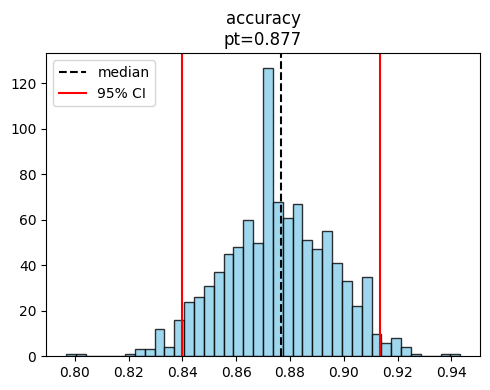

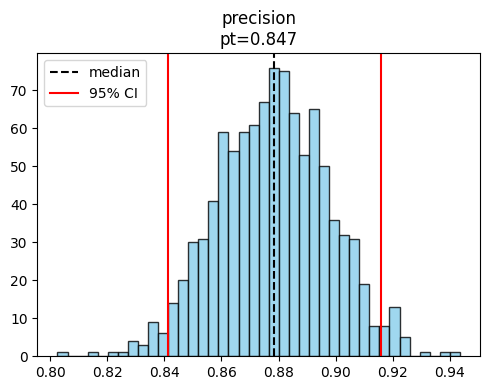

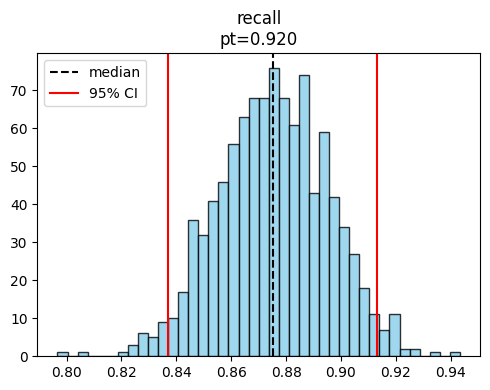

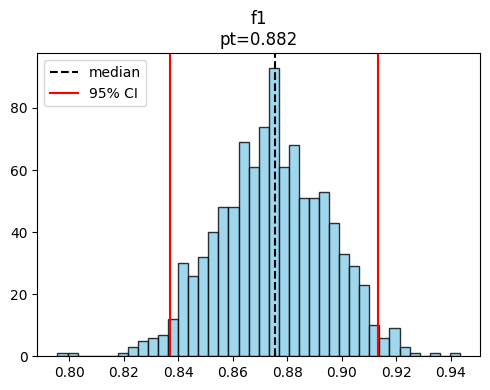

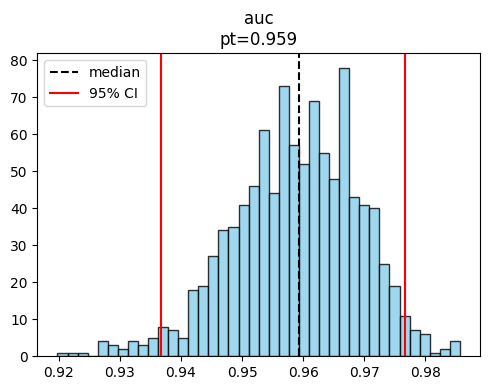

In [33]:
plot_bootstrap_metrics(
    metrics_boot, 
    df_results, 
    n_cols=0,        # number of columns in grid (set 0 for separate plots, 2 or 3 for grid)
    w_pad=0.5,       # horizontal space between columns (increase -> wider gap)
    h_pad=1.0,       # vertical space between rows (increase -> taller gap)
    shift_factor=0.0 # how much to horizontally shift last-row plots for centering
)


--------------------
Gradcam ++ (more advance visualization than previous version of mine)

In [34]:
# ================= Grad-CAM++ Class =================
class GradCAMPlusPlus:
    def __init__(self, model, target_layer, labels):
        self.model = model
        self.labels = labels
        try:
            self.target_layer = model.get_layer(target_layer)
        except:
            print(f"❌ Layer '{target_layer}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        print(f"✓ Grad-CAM++ initialized with layer: {target_layer}")

    def compute_gradcam_plus_plus(self, image, class_idx):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        intermediate_model = Model(inputs=self.model.input, outputs=[self.target_layer.output, self.model.output])
        with tf.GradientTape() as tape:
            layer_output, predictions = intermediate_model(img_tensor)
            tape.watch(layer_output)
            loss = predictions[0, class_idx]
        gradients = tape.gradient(loss, layer_output)
        layer_output_np = layer_output.numpy()[0]
        gradients_np = gradients.numpy()[0]
        second_deriv = np.power(gradients_np, 2)
        third_deriv = second_deriv * gradients_np
        alpha_denom = 2 * second_deriv + np.sum(third_deriv * layer_output_np, axis=(0, 1), keepdims=True)
        alpha_denom = np.where(alpha_denom != 0, alpha_denom, 1e-8)
        alpha = second_deriv / alpha_denom
        alpha = np.maximum(alpha, 0)
        weights = np.sum(alpha * np.maximum(gradients_np, 0), axis=(0, 1))
        weights = weights / (np.sum(weights) + 1e-8)
        cam = np.zeros(layer_output_np.shape[:2])
        for i, w in enumerate(weights):
            cam += w * layer_output_np[:, :, i]
        cam = np.maximum(cam, 0)
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def predict_and_explain(self, image):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])
        gradcam = self.compute_gradcam_plus_plus(image, pred_idx)
        gradcam_resized = tf.image.resize(tf.expand_dims(gradcam, -1), image.shape[:2]).numpy()[..., 0]
        return {'prediction': self.labels[pred_idx], 'confidence': confidence, 'gradcam': gradcam_resized, 'preds': preds}

    def visualize_gradcam_plus_plus(self, image, figsize=(14, 4)):
        result = self.predict_and_explain(image)
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(f'Grad-CAM++: {result["prediction"]} ({result["confidence"]:.1%})', fontsize=14, fontweight='bold')
        # Original image
        axes[0].imshow(np.clip(image*255,0,255).astype(np.uint8)); axes[0].set_title('Original'); axes[0].axis('off')
        # Heatmap overlay
        axes[1].imshow(np.clip(image*255,0,255).astype(np.uint8), alpha=1.0)
        im = axes[1].imshow(result['gradcam'], cmap='jet', alpha=0.5)
        axes[1].set_title('Grad-CAM++ Heatmap'); axes[1].axis('off'); plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        # Blended overlay
        img_norm = image/255.0 if image.max()>1 else image
        heatmap_rgb = plt.cm.jet(result['gradcam'])[..., :3]
        alpha_blend = result['gradcam'][..., np.newaxis]
        overlay = (1-alpha_blend)*img_norm + alpha_blend*heatmap_rgb
        overlay = np.clip(overlay, 0, 1)
        axes[2].imshow(overlay); axes[2].set_title('Blended Overlay'); axes[2].axis('off')
        plt.tight_layout()
        return fig

(224, 224, 3)
✓ Grad-CAM++ initialized with layer: conv2d_23


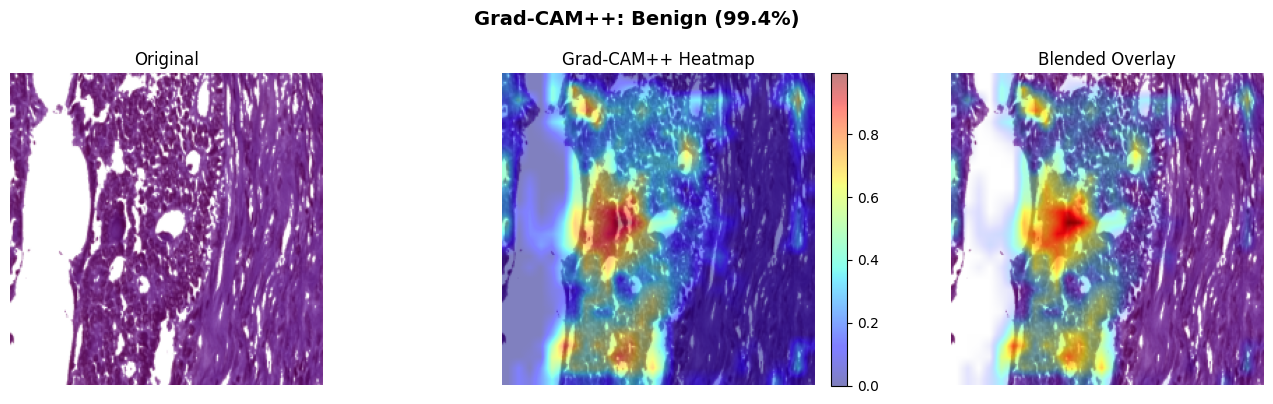

In [35]:
# ================= Example Usage =================
target_layer = 'conv2d_23'    #'conv2d_72'  
image = test_data[0][0][0]
print(image.shape)
explainer = GradCAMPlusPlus(model, target_layer, labels)
fig = explainer.visualize_gradcam_plus_plus(image)
plt.show()

In [36]:
# ================= Score-CAM Class =================
class ScoreCAM:
    def __init__(self, model, target_layer, labels, max_channels=32):
        self.model = model
        self.labels = labels
        self.max_channels = max_channels
        try:
            self.target_layer = model.get_layer(target_layer)
        except:
            print(f"❌ Layer '{target_layer}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        print(f"✓ Score-CAM initialized with layer: {target_layer}")

    def compute_scorecam(self, image, class_idx):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)

        # Model for feature maps
        feature_model = Model(self.model.input, self.target_layer.output)
        feature_maps = feature_model(img_tensor)[0]  # (H, W, C)

        num_channels = min(feature_maps.shape[-1], self.max_channels)
        cam = np.zeros(feature_maps.shape[:2], dtype=np.float32)

        for i in range(num_channels):
            fmap = feature_maps[..., i]

            # Normalize activation map
            fmap = np.maximum(fmap, 0)
            if fmap.max() == 0:
                continue
            fmap_norm = fmap / (fmap.max() + 1e-8)

            # Resize to input size
            fmap_resized = tf.image.resize(
                fmap_norm[..., np.newaxis], image.shape[:2]
            ).numpy()

            # Mask input image
            masked_img = image * fmap_resized

            # Get class score
            masked_tensor = tf.expand_dims(masked_img, 0)
            score = self.model(masked_tensor, training=False)[0, class_idx]

            cam += score.numpy() * fmap_norm

        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def predict_and_explain(self, image):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])

        scorecam = self.compute_scorecam(image, pred_idx)
        scorecam_resized = tf.image.resize(
            scorecam[..., np.newaxis], image.shape[:2]
        ).numpy()[..., 0]

        return {
            'prediction': self.labels[pred_idx],
            'confidence': confidence,
            'scorecam': scorecam_resized,
            'preds': preds
        }

    def visualize_scorecam(self, image, figsize=(14, 4)):
        result = self.predict_and_explain(image)

        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(
            f'Score-CAM: {result["prediction"]} ({result["confidence"]:.1%})',
            fontsize=14, fontweight='bold'
        )

        # Original image
        axes[0].imshow(np.clip(image*255,0,255).astype(np.uint8))
        axes[0].set_title('Original')
        axes[0].axis('off')

        # Heatmap overlay
        axes[1].imshow(np.clip(image*255,0,255).astype(np.uint8))
        im = axes[1].imshow(result['scorecam'], cmap='jet', alpha=0.5)
        axes[1].set_title('Score-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        # Blended overlay
        img_norm = image/255.0 if image.max()>1 else image
        heatmap_rgb = plt.cm.jet(result['scorecam'])[..., :3]
        alpha = result['scorecam'][..., np.newaxis]
        overlay = (1-alpha)*img_norm + alpha*heatmap_rgb
        overlay = np.clip(overlay, 0, 1)

        axes[2].imshow(overlay)
        axes[2].set_title('Blended Overlay')
        axes[2].axis('off')

        plt.tight_layout()
        return fig


✓ Score-CAM initialized with layer: conv2d_23


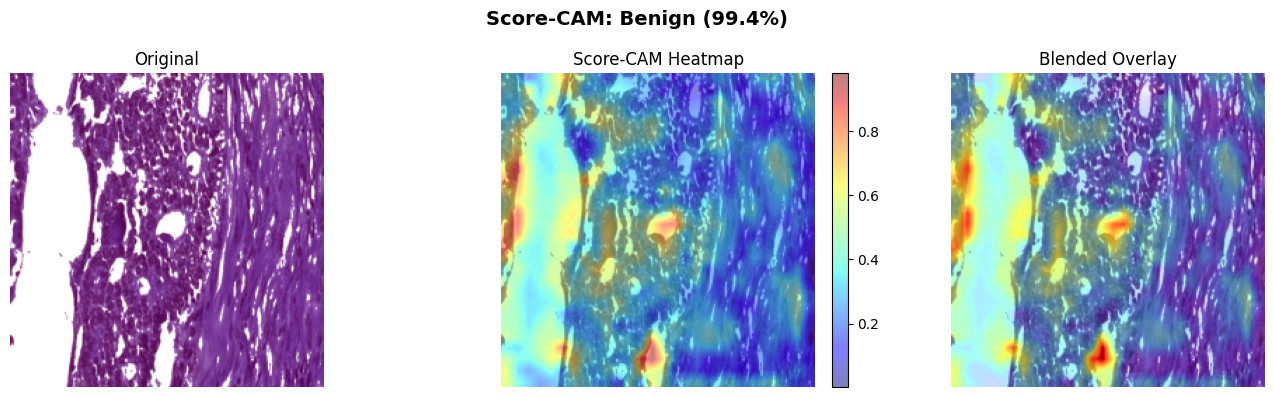

In [37]:
target_layer = 'conv2d_23'
image = test_data[0][0][0]

explainer = ScoreCAM(model, target_layer, labels)
fig = explainer.visualize_scorecam(image)
plt.show()